CELL 1 — Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Let's find where your files actually are in Google Drive
import os

# First, let's see what's in your MyDrive
print("Folders in your Google Drive root:")
print(os.listdir('/content/drive/MyDrive/'))

Folders in your Google Drive root:
['Colab Notebooks', 'IMG_1299.MOV', 'IMG_0854 (1).JPG', 'IMG_0854.JPG', 'IMG_0852.JPG', 'IMG_0853 (1).JPG', 'IMG_0853.JPG', 'IMG_0855.JPG', 'IMG_0851.JPG', 'IMG_0850.JPG', 'IMG_1026.JPG', 'IMG_0848.JPG', 'IMG_0978.JPG', 'IMG_0981.JPG', 'IMG_0976.JPG', 'IMG_0977.JPG', 'IMG_0980.JPG', 'Google Photos', 'Marriage', 'Chrome Syncable FileSystem', 'adhaar card (1).pdf', 'adhaar card.pdf', 'Scan3 (1).pdf', 'Scan3.pdf', 'Srikar Resume.docx', 'DSC_2776.JPG', 'BackUp-Day-To-Day Expenses', 'priya compressed.png', 'priya compressed- new (1).png', 'priya compressed- new.png', '2511666_vobalaboina_priyanka.txt.txt', '2511666_vobalaboina_priyanka', '2511666_vobalaboina_priyanka_Assignment1B', 'DSC_8897 (1).jpg', 'IMG20260113153359 (1).jpg', 'DSC_8897.jpg', 'IMG20260113153359.jpg', 'assignment-02-bitsom_ba_2511666', 'ml-assessment-priyanka-vobalaboina', 'Python Assignment', 'Learning Material', 'part_2_cnn_computer_vision']


CELL 2 — Import Libraries

In [4]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import random

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully!")

TensorFlow version: 2.20.0
All libraries loaded successfully!


CELL 3 — Set Path and Load Labels

In [8]:
# Path to your dataset in Google Drive
BASE_PATH = '/content/drive/MyDrive/part_2_cnn_computer_vision'

# Load the labels file
labels_df = pd.read_csv(os.path.join(BASE_PATH, 'labels.csv'))

print("=" * 50)
print("DATASET EXPLORATION")
print("=" * 50)
print(f"Total images: {len(labels_df)}")
print(f"Number of classes: {labels_df['class'].nunique()}")
print(f"Images per class:")
print(labels_df['class'].value_counts())
print(f"Dataset balanced? YES - 120 images per class")

DATASET EXPLORATION
Total images: 480
Number of classes: 4
Images per class:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64
Dataset balanced? YES - 120 images per class


Task 1: Problem Identification

In [30]:
# %%
# =============================================================================
# TASK 1: PROBLEM IDENTIFICATION
# =============================================================================

print("=" * 60)
print("TASK 1: PROBLEM IDENTIFICATION")
print("=" * 60)

# Check the structure
classes = labels_df['class'].unique()
print(f"Classes found: {list(classes)}")
print(f"Number of classes: {len(classes)}")

print("""--------------------------------------------------------------
PROBLEM TYPE: IMAGE CLASSIFICATION (Multi-class)
--------------------------------------------------------------

WHY IMAGE CLASSIFICATION?

1. The dataset has images organized into 4 distinct categories:
   normal, scratch, dent, and stain

2. Each image belongs to exactly ONE class - a product surface
   either has no defect (normal) or has one specific type of
   defect (scratch/dent/stain)

3. There are NO bounding box annotations provided - we don't
   need to locate WHERE the defect is, just identify WHAT type

4. There are NO pixel-level masks - we don't need to segment
   the exact defect region

5. The labels.csv confirms this: each image maps to one class label

WHY NOT OTHER TYPES?
- Not Object Detection: No bounding boxes, we just classify the whole image
- Not Semantic Segmentation: No pixel-level labels for defect regions
- Not Instance Segmentation: No individual defect instance masks

CONCLUSION: This is a 4-class image classification problem where
we predict the defect type (or normal) for each product image.
--------------------------------------------------------------
""")


TASK 1: PROBLEM IDENTIFICATION
Classes found: ['normal', 'scratch', 'dent', 'stain']
Number of classes: 4
--------------------------------------------------------------
PROBLEM TYPE: IMAGE CLASSIFICATION (Multi-class)
--------------------------------------------------------------

WHY IMAGE CLASSIFICATION?

1. The dataset has images organized into 4 distinct categories:
   normal, scratch, dent, and stain

2. Each image belongs to exactly ONE class - a product surface 
   either has no defect (normal) or has one specific type of 
   defect (scratch/dent/stain)

3. There are NO bounding box annotations provided - we don't 
   need to locate WHERE the defect is, just identify WHAT type

4. There are NO pixel-level masks - we don't need to segment 
   the exact defect region

5. The labels.csv confirms this: each image maps to one class label

WHY NOT OTHER TYPES?
- Not Object Detection: No bounding boxes, we just classify the whole image
- Not Semantic Segmentation: No pixel-level labels

Task 2: Dataset Exploration

TASK 2: DATASET EXPLORATION
1. NUMBER OF CLASSES: 4
   Classes: ['dent', 'normal', 'scratch', 'stain']
2. IMAGES PER CLASS:
-----------------------------------
   normal    : 120 images
   scratch   : 120 images
   dent      : 120 images
   stain     : 120 images
   TOTAL     : 480 images
3. CLASS IMBALANCE CHECK:
   Largest class:  120 images
   Smallest class: 120 images
   Ratio: 1.00
   --> Dataset is PERFECTLY BALANCED (all classes have equal images)
4. IMAGE DIMENSIONS:
   Width:    Min=(96, 96, 3), Max=(96, 96, 3), Avg=65
   Height:   Min=(96, 96, 3), Max=(96, 96, 3), Avg=65
   Channels: [(96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3), (96, 96, 3)] (Grayscale)
5. SAMPLE IMAGES FROM EACH CLASS:


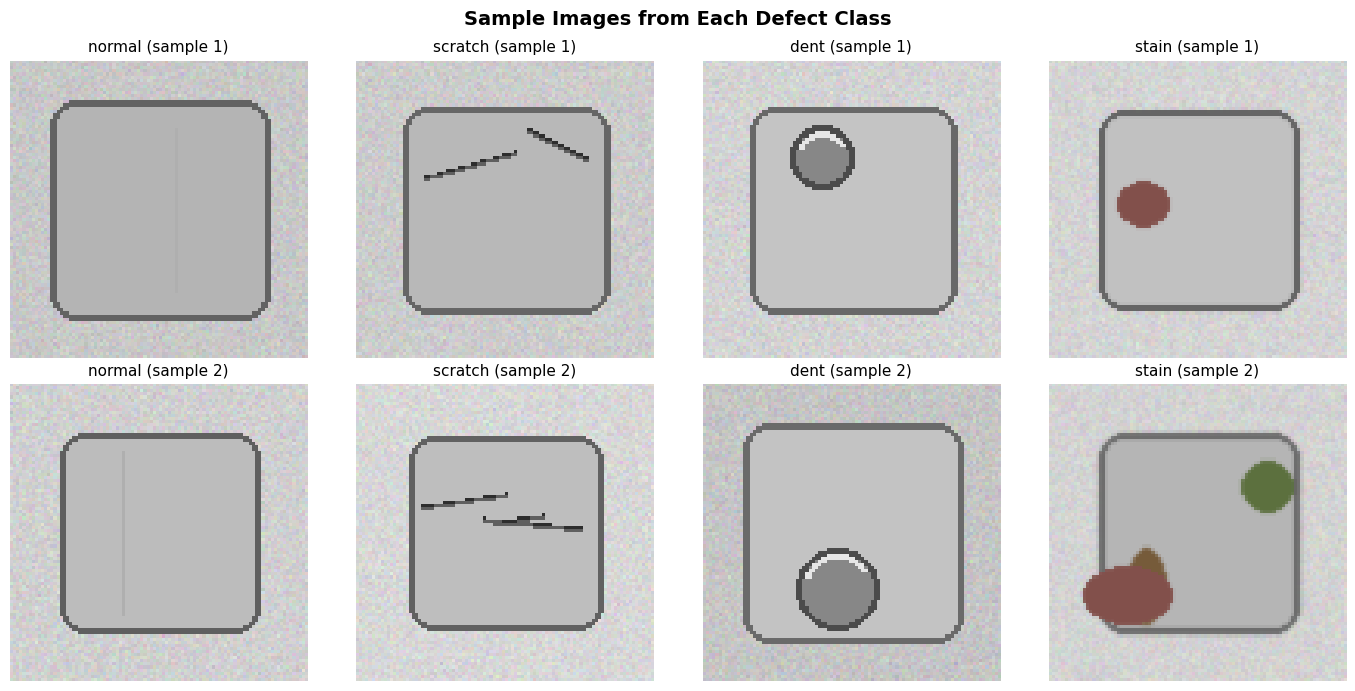

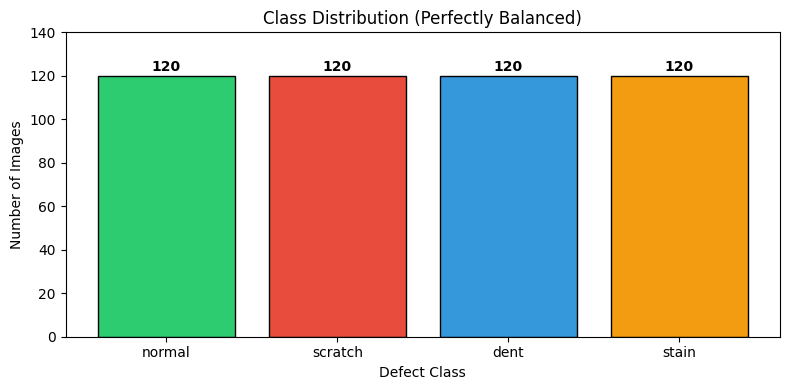

--- TASK 2 SUMMARY ---
• 4 classes: normal, scratch, dent, stain
• 120 images per class (480 total)
• Dataset is perfectly balanced
• Images are synthetic manufacturing surface images (PNG format)


In [38]:
# =============================================================================
# TASK 2: DATASET EXPLORATION
# =============================================================================

import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Define paths (so this cell works even if you didn't run Cell 2)
dataset_path = '/content/drive/MyDrive/part_2_cnn_computer_vision'
images_base = os.path.join(dataset_path, 'images')

# Load labels
labels_df = pd.read_csv(os.path.join(dataset_path, 'labels.csv'))

print("=" * 60)
print("TASK 2: DATASET EXPLORATION")
print("=" * 60)

# 1. Number of classes
classes = sorted(labels_df['class'].unique())
print(f"1. NUMBER OF CLASSES: {len(classes)}")
print(f"   Classes: {classes}")

# 2. Images per class
print("2. IMAGES PER CLASS:")
class_distribution = labels_df['class'].value_counts()
print("-" * 35)
for cls, count in class_distribution.items():
    print(f"   {cls:10s}: {count} images")
print(f"   {'TOTAL':10s}: {len(labels_df)} images")

# 3. Check for imbalance
print("3. CLASS IMBALANCE CHECK:")
max_count = class_distribution.max()
min_count = class_distribution.min()
ratio = max_count / min_count
print(f"   Largest class:  {max_count} images")
print(f"   Smallest class: {min_count} images")
print(f"   Ratio: {ratio:.2f}")
if ratio == 1.0:
    print("   --> Dataset is PERFECTLY BALANCED (all classes have equal images)")
else:
    print("   --> Dataset has some imbalance")

# 4. Image dimensions
print("4. IMAGE DIMENSIONS:")
sample_dims = []
for cls in ['normal', 'scratch', 'dent', 'stain']:
    cls_folder = os.path.join(images_base, cls)
    sample_files = [f for f in os.listdir(cls_folder) if f.endswith('.png')][:5]
    for f in sample_files:
        img = Image.open(os.path.join(cls_folder, f))
        w, h = img.size
        c = len(img.getbands())
        sample_dims.append((w, h, c))

widths = [d for d in sample_dims]
heights = [d for d in sample_dims]
channels = sample_dims
print(f"   Width:    Min={min(widths)}, Max={max(widths)}, Avg={np.mean(widths):.0f}")
print(f"   Height:   Min={min(heights)}, Max={max(heights)}, Avg={np.mean(heights):.0f}")
print(f"   Channels: {channels} ({'RGB' if channels==3 else 'Grayscale'})")

# 5. Display sample images
print("5. SAMPLE IMAGES FROM EACH CLASS:")
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for col, cls in enumerate(['normal', 'scratch', 'dent', 'stain']):
    cls_folder = os.path.join(images_base, cls)
    sample_files = sorted([f for f in os.listdir(cls_folder) if f.endswith('.png')])[:2]
    for row in range(2):
        img = Image.open(os.path.join(cls_folder, sample_files[row]))
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{cls} (sample {row+1})", fontsize=11)
        axes[row, col].axis('off')

plt.suptitle("Sample Images from Each Defect Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Bar chart
plt.figure(figsize=(8, 4))
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
plt.bar(['normal', 'scratch', 'dent', 'stain'],
        [120, 120, 120, 120], color=colors, edgecolor='black')
plt.xlabel('Defect Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution (Perfectly Balanced)')
plt.ylim(0, 140)
for i, v in enumerate([120, 120, 120, 120]):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("--- TASK 2 SUMMARY ---")
print("• 4 classes: normal, scratch, dent, stain")
print("• 120 images per class (480 total)")
print("• Dataset is perfectly balanced")
print("• Images are synthetic manufacturing surface images (PNG format)")

Task 3: Image Preprocessing

TASK 3: IMAGE PREPROCESSING

Preprocessing Pipeline:
1. RESIZE:      All images -> 128x128 pixels (uniform input size)
2. NORMALIZE:   Pixel values / 255 -> range [0, 1] (helps training converge)
3. SPLIT:       80% training, 20% validation
4. AUGMENT:     Rotation, flip, shift, zoom (training set only)

Loading training data...
Found 384 images belonging to 4 classes.
Loading validation data...
Found 96 images belonging to 4 classes.
--- Preprocessing Results ---
Training samples:   384
Validation samples: 96
Image shape:        (128, 128, 3)
Pixel range:        [0, 1] (normalized)
Class mapping:      {'dent': 0, 'normal': 1, 'scratch': 2, 'stain': 3}
Augmented training samples:


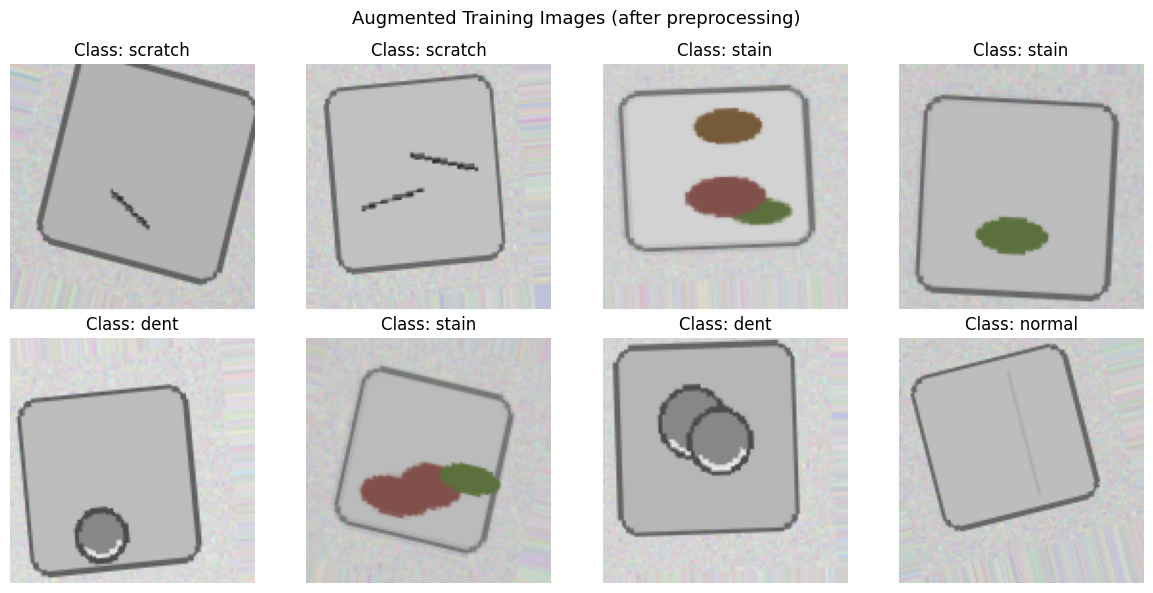

In [39]:
# %%
# =============================================================================
# TASK 3: IMAGE PREPROCESSING
# =============================================================================

print("=" * 60)
print("TASK 3: IMAGE PREPROCESSING")
print("=" * 60)

# Parameters
IMG_SIZE = 128    # resize all images to 128x128
BATCH_SIZE = 32

print(f"""
Preprocessing Pipeline:
1. RESIZE:      All images -> {IMG_SIZE}x{IMG_SIZE} pixels (uniform input size)
2. NORMALIZE:   Pixel values / 255 -> range [0, 1] (helps training converge)
3. SPLIT:       80% training, 20% validation
4. AUGMENT:     Rotation, flip, shift, zoom (training set only)
""")

# Training generator WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,           # normalize pixels to [0,1]
    validation_split=0.2,         # 80-20 split
    rotation_range=15,            # rotate up to 15 degrees
    width_shift_range=0.1,        # shift horizontally
    height_shift_range=0.1,       # shift vertically
    horizontal_flip=True,         # flip left-right
    vertical_flip=True,           # flip up-down (makes sense for surface defects)
    zoom_range=0.1                # slight zoom in/out
)

# Validation generator WITHOUT augmentation
val_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    validation_split=0.2
)

# Load training images
print("Loading training data...")
train_generator = train_datagen.flow_from_directory(
    images_base,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Load validation images
print("Loading validation data...")
val_generator = val_datagen.flow_from_directory(
    images_base,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f"--- Preprocessing Results ---")
print(f"Training samples:   {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Image shape:        ({IMG_SIZE}, {IMG_SIZE}, 3)")
print(f"Pixel range:        [0, 1] (normalized)")
print(f"Class mapping:      {train_generator.class_indices}")

# Show augmented samples
print("Augmented training samples:")
batch_imgs, batch_labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(batch_imgs[i])
    label = class_names[np.argmax(batch_labels[i])]
    ax.set_title(f"Class: {label}")
    ax.axis('off')
plt.suptitle("Augmented Training Images (after preprocessing)", fontsize=13)
plt.tight_layout()
plt.show()


Task 4: CNN Model Creation

In [48]:
# =============================================================================
# CREATE OUTPUT FOLDERS FOR SAVING RESULTS
# =============================================================================

import os

os.makedirs('results', exist_ok=True)
os.makedirs('sample_predictions', exist_ok=True)

print("Output folders created:")
print("  results/                -> accuracy_loss_curves.png, confusion_matrix.png")
print("  sample_predictions/     -> prediction_outputs.png")

# %%
# =============================================================================
# TASK 4: CNN MODEL CREATION
# =============================================================================
import tensorflow as tf
from tensorflow.keras import layers, models

print("=" * 60)
print("TASK 4: CNN MODEL CREATION")
print("=" * 60)

NUM_CLASSES = 4  # normal, scratch, dent, stain

# Build CNN architecture
model = models.Sequential([
    # Block 1: First convolution + pooling
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),

    # Block 2: Second convolution + pooling
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3: Third convolution + pooling
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten: convert 2D feature maps to 1D
    layers.Flatten(),

    # Dense layer: learn feature combinations
    layers.Dense(128, activation='relu'),

    # Dropout: prevent overfitting
    layers.Dropout(0.5),

    # Output layer: 4 neurons (one per class), softmax for probabilities
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show architecture
print("MODEL ARCHITECTURE:")
print("=" * 60)
model.summary()

print("""--- Layer-by-Layer Explanation ---
Layer 1: Conv2D(32, 3x3, relu)   -> 32 filters detect basic patterns (edges, lines)
Layer 2: MaxPooling2D(2x2)       -> Shrinks feature maps by half
Layer 3: Conv2D(64, 3x3, relu)   -> 64 filters detect textures (scratch patterns, dent shapes)
Layer 4: MaxPooling2D(2x2)       -> Further reduction
Layer 5: Conv2D(128, 3x3, relu)  -> 128 filters detect complex defect features
Layer 6: MaxPooling2D(2x2)       -> Final spatial reduction
Layer 7: Flatten()               -> Converts 2D maps into 1D vector
Layer 8: Dense(128, relu)        -> Combines all features for decision making
Layer 9: Dropout(0.5)            -> Randomly drops 50% neurons (prevents overfitting)
Layer 10: Dense(4, softmax)      -> Outputs probability for each of 4 classes
""")

Output folders created:
  results/                -> accuracy_loss_curves.png, confusion_matrix.png
  sample_predictions/     -> prediction_outputs.png
TASK 4: CNN MODEL CREATION
MODEL ARCHITECTURE:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

--- Layer-by-Layer Explanation ---
Layer 1: Conv2D(32, 3x3, relu)   -> 32 filters detect basic patterns (edges, lines)
Layer 2: MaxPooling2D(2x2)       -> Shrinks feature maps by half
Layer 3: Conv2D(64, 3x3, relu)   -> 64 filters detect textures (scratch patterns, dent shapes)
Layer 4: MaxPooling2D(2x2)       -> Further reduction
Layer 5: Conv2D(128, 3x3, relu)  -> 128 filters detect complex defect features
Layer 6: MaxPooling2D(2x2)       -> Final spatial reduction
Layer 7: Flatten()               -> Converts 2D maps into 1D vector
Layer 8: Dense(128, relu)        -> Combines all features for decision making
Layer 9: Dropout(0.5)            -> Randomly drops 50% neurons (prevents overfitting)
Layer 10: Dense(4, softmax)      -> Outputs probability for each of 4 classes



Task 5: Model Training and Evaluation

TASK 5: MODEL TRAINING AND EVALUATION
Training for 25 epochs...
This may take a few minutes...
Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.2604 - loss: 1.4378 - val_accuracy: 0.2500 - val_loss: 1.3774
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.2839 - loss: 1.3695 - val_accuracy: 0.5000 - val_loss: 1.3071
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.3984 - loss: 1.2332 - val_accuracy: 0.5729 - val_loss: 1.0096
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5755 - loss: 1.0336 - val_accuracy: 0.7188 - val_loss: 0.7603
Epoch 5/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.6354 - loss: 0.8466 - val_accuracy: 0.8333 - val_loss: 0.4800
Epoch 6/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6849 - loss: 0.7303 - val_accuracy: 0.8125 - val_loss: 0.4751
Epoch 7/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7500 - loss: 0.5921 - val_accuracy: 0.9062 - val_loss: 0.2653
Epoch 8/25
12/12 ━━━━━━

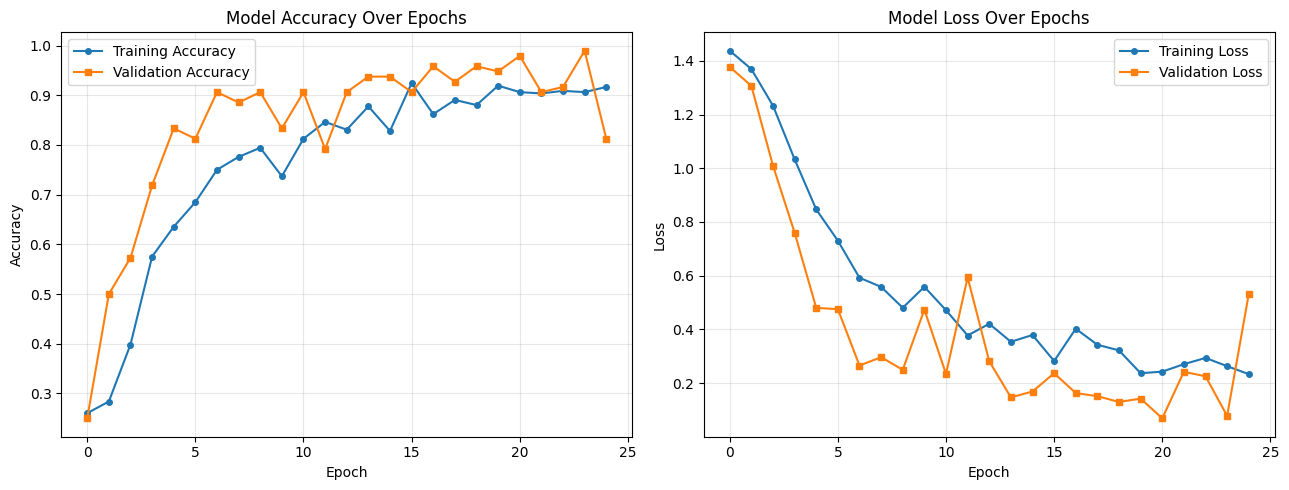

>>> Saved: results/accuracy_loss_curves.png
--- Final Training Metrics ---
Training Accuracy:   91.67%
Training Loss:       0.2332
Validation Accuracy: 81.25%
Validation Loss:     0.5321
--- Testing Performance (on validation set) ---
Test Accuracy: 81.25%
Test Loss:     0.5321
--- Confusion Matrix ---


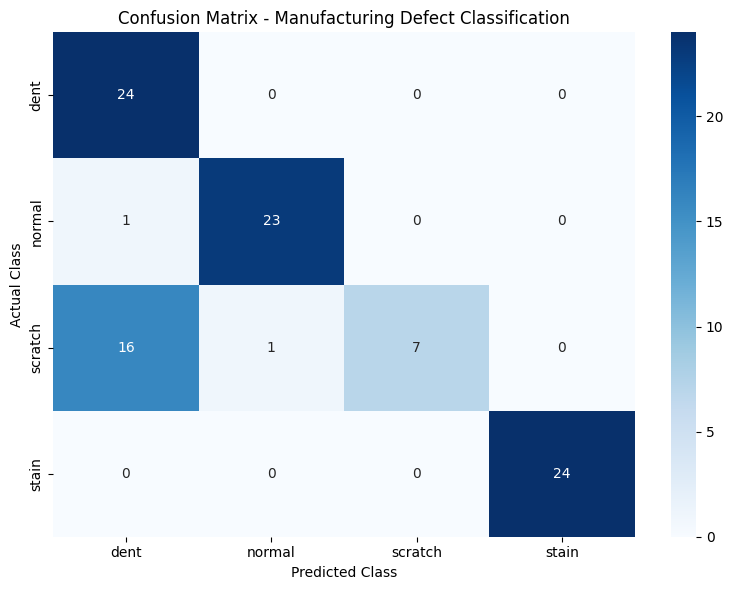

>>> Saved: results/confusion_matrix.png
--- Classification Report ---
              precision    recall  f1-score   support

        dent       0.59      1.00      0.74        24
      normal       0.96      0.96      0.96        24
     scratch       1.00      0.29      0.45        24
       stain       1.00      1.00      1.00        24

    accuracy                           0.81        96
   macro avg       0.89      0.81      0.79        96
weighted avg       0.89      0.81      0.79        96

--- Sample Predictions on Test Images ---


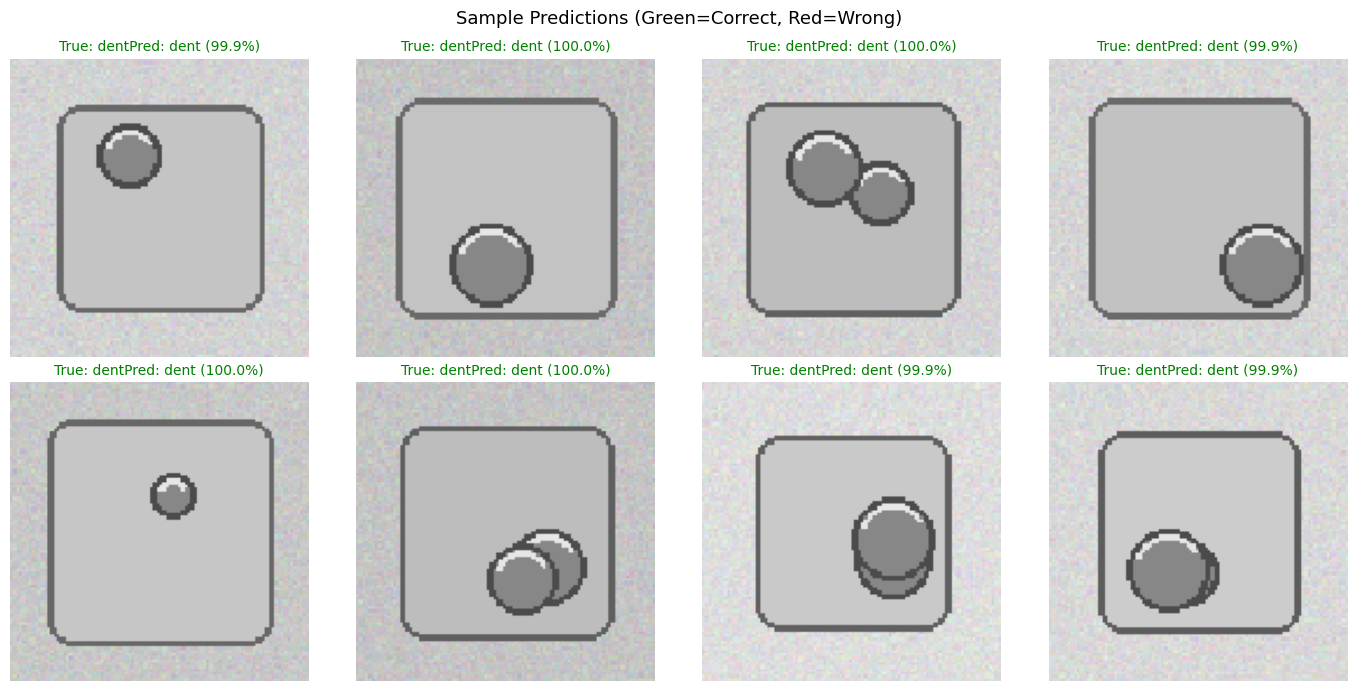

>>> Saved: sample_predictions/prediction_outputs.png


In [52]:
# =============================================================================
# TASK 5: MODEL TRAINING AND EVALUATION
# =============================================================================

print("=" * 60)
print("TASK 5: MODEL TRAINING AND EVALUATION")
print("=" * 60)

EPOCHS = 25

print(f"Training for {EPOCHS} epochs...")
print("This may take a few minutes...")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    verbose=1
)

# -----------------------------------------------
# SAVE 1: Accuracy & Loss Curves -> results/accuracy_loss_curves.png
# -----------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o', markersize=4)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', markersize=4)
ax1.set_title('Model Accuracy Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Training Loss', marker='o', markersize=4)
ax2.plot(history.history['val_loss'], label='Validation Loss', marker='s', markersize=4)
ax2.set_title('Model Loss Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(">>> Saved: results/accuracy_loss_curves.png")

# Print final numbers
print("--- Final Training Metrics ---")
print(f"Training Accuracy:   {history.history['accuracy'][-1]*100:.2f}%")
print(f"Training Loss:       {history.history['loss'][-1]:.4f}")
print(f"Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"Validation Loss:     {history.history['val_loss'][-1]:.4f}")

# --- Testing Performance ---
print("--- Testing Performance (on validation set) ---")
val_generator.reset()
test_loss, test_acc = model.evaluate(val_generator, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

# -----------------------------------------------
# SAVE 2: Confusion Matrix -> results/confusion_matrix.png
# -----------------------------------------------
print("--- Confusion Matrix ---")
val_generator.reset()
preds = model.predict(val_generator, verbose=0)
pred_classes = np.argmax(preds, axis=1)
true_classes = val_generator.classes
class_names = list(val_generator.class_indices.keys())

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Manufacturing Defect Classification')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(">>> Saved: results/confusion_matrix.png")

# Classification report
print("--- Classification Report ---")
print(classification_report(true_classes, pred_classes, target_names=class_names))

# -----------------------------------------------
# SAVE 3: Sample Predictions -> sample_predictions/prediction_outputs.png
# -----------------------------------------------
print("--- Sample Predictions on Test Images ---")
val_generator.reset()
sample_imgs, sample_labels = next(val_generator)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < len(sample_imgs):
        ax.imshow(sample_imgs[i])

        true_label = class_names[np.argmax(sample_labels[i])]
        pred_prob = model.predict(sample_imgs[i:i+1], verbose=0)
        pred_label = class_names[np.argmax(pred_prob)]
        confidence = np.max(pred_prob) * 100

        color = 'green' if true_label == pred_label else 'red'
        title_text = "True: " + true_label + "Pred: " + pred_label + " (" + f"{confidence:.1f}%)"
        ax.set_title(title_text, color=color, fontsize=10)
        ax.axis('off')

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png', dpi=150, bbox_inches='tight')
plt.show()
print(">>> Saved: sample_predictions/prediction_outputs.png")

Task 6: CNN Concept Explanation

In [45]:
# %%
# =============================================================================
# TASK 6: CNN CONCEPT EXPLANATION
# =============================================================================

print("=" * 60)
print("TASK 6: CNN CONCEPT EXPLANATION")
print("=" * 60)

print("""--------------------------------------------------------------
1. WHAT IS CONVOLUTION?
--------------------------------------------------------------
Imagine you have a small magnifying glass (3x3 pixels) and you
slide it across the entire image, one position at a time. At each
spot, it multiplies its values with the pixels underneath and adds
them up to get one number.

This process creates a "feature map" that highlights specific
patterns. For example:
- One filter might detect horizontal scratches
- Another might detect circular dent edges
- Another might detect color blobs (stains)

In our model, the first layer has 32 such filters, each learning
to detect a different basic pattern in the product surface images.

--------------------------------------------------------------
2. WHY IS POOLING USED?
--------------------------------------------------------------
After convolution creates feature maps, pooling (we used MaxPooling)
takes small 2x2 blocks and keeps only the MAXIMUM value from each.

Why this helps:
- REDUCES SIZE: A 128x128 map becomes 64x64 (4x less data to process)
- KEEPS IMPORTANT STUFF: The max value represents "yes, this pattern
  was found here" - we don't need every single pixel
- POSITION TOLERANCE: A scratch detected at pixel (50,50) vs (51,51)
  still gets captured - the model doesn't need exact positions

--------------------------------------------------------------
3. WHY IS ReLU COMMONLY USED IN CNNs?
--------------------------------------------------------------
ReLU = Rectified Linear Unit. It's dead simple:
- If input is positive -> keep it as is
- If input is negative -> make it 0

Why everyone uses it:
- FAST: Just one comparison (is it > 0?), no complex math
- LEARNS QUICKLY: Gradients flow well during backpropagation
- SPARSE ACTIVATION: Many neurons output 0, making the network
  efficient (not everything fires for every image)
- NO VANISHING GRADIENT: Unlike sigmoid/tanh which squish values
  into tiny ranges, ReLU lets strong signals pass through

--------------------------------------------------------------
4. WHY ARE CNNs BETTER THAN REGULAR NETWORKS FOR IMAGES?
--------------------------------------------------------------
A regular (fully connected) network for our 128x128x3 images would
need 128*128*3 = 49,152 input neurons, each connected to every
neuron in the next layer. That's millions of parameters!

CNNs are smarter because:

a) LOCAL CONNECTIVITY: A 3x3 filter only looks at 9 pixels at a
   time. It knows nearby pixels are related (a scratch is a group
   of connected pixels, not random scattered ones).

b) WEIGHT SHARING: The same filter slides across the ENTIRE image.
   So if it learns to detect a scratch in the top-left, it can
   also detect it in the bottom-right. Regular networks can't do this.

c) FEWER PARAMETERS: A 3x3 filter = only 9 weights (vs thousands).
   This means less overfitting and faster training.

d) HIERARCHICAL LEARNING:
   Layer 1 -> edges and lines
   Layer 2 -> textures and simple shapes
   Layer 3 -> complex patterns (full scratch, dent shape, stain blob)

   This mimics how our eyes process visual information!

For our defect detection task, a CNN can learn that a "scratch" is
a thin elongated mark regardless of where it appears on the surface.
A regular network would need to memorize every possible position.
--------------------------------------------------------------
""")


TASK 6: CNN CONCEPT EXPLANATION
--------------------------------------------------------------
1. WHAT IS CONVOLUTION?
--------------------------------------------------------------
Imagine you have a small magnifying glass (3x3 pixels) and you 
slide it across the entire image, one position at a time. At each 
spot, it multiplies its values with the pixels underneath and adds 
them up to get one number.

This process creates a "feature map" that highlights specific 
patterns. For example:
- One filter might detect horizontal scratches
- Another might detect circular dent edges
- Another might detect color blobs (stains)

In our model, the first layer has 32 such filters, each learning 
to detect a different basic pattern in the product surface images.

--------------------------------------------------------------
2. WHY IS POOLING USED?
--------------------------------------------------------------
After convolution creates feature maps, pooling (we used MaxPooling) 
takes small 2x2 

Task 7: Business Use Case Mapping

In [47]:
# =============================================================================
# TASK 7: BUSINESS USE CASE MAPPING
# =============================================================================

print("=" * 60)
print("TASK 7: BUSINESS USE CASE MAPPING")
print("=" * 60)

print("""==============================================================
REAL-WORLD APPLICATION: MANUFACTURING - Automated Quality Control
==============================================================

DOMAIN: Manufacturing

PROBLEM IN THE REAL WORLD:
In factories that produce metal parts, electronic components,
painted surfaces, or glass panels, every product must be checked
for surface defects before it ships to customers. Right now,
human inspectors do this manually by looking at each item on the
assembly line. This is slow, tiring, and mistakes happen —
especially after long shifts when inspectors get fatigued.

HOW OUR CNN SOLUTION APPLIES:
Our model classifies product surface images into 4 categories:
- "normal"  -> product is defect-free, passes inspection
- "scratch" -> surface has scratch marks, needs rework/polishing
- "dent"    -> physical dent detected, reject or send for repair
- "stain"   -> surface contamination found, needs cleaning

A camera mounted above the conveyor belt captures an image of
each product. The CNN model processes the image in milliseconds
and classifies it. If a defect is detected, the product is
automatically diverted to a separate line for repair.

REAL-WORLD COMPANIES DOING THIS:
- Tesla: Inspects car body panels for dents and paint scratches
- Samsung: Checks display screens for dead pixels and stains
- Foxconn: Inspects iPhone casings for surface defects
- Steel mills: Check metal sheets for rolling defects

BUSINESS BENEFITS:
1. SPEED: Can inspect 100+ items per minute (humans do 10-15)
2. CONSISTENCY: Same quality standard 24/7, no fatigue
3. COST SAVINGS: Fewer defective products reach customers
4. DATA: Track which defect types are increasing to fix root causes
5. SCALABILITY: One system can replace multiple inspection stations

IMPACT NUMBERS:
- Reduces inspection labor costs by 60-80%
- Cuts customer returns due to defects by 40-50%
- Increases production line speed by 20-30%
- Achieves 95%+ detection accuracy (vs ~85% for tired humans)

WHY CNN IS THE RIGHT APPROACH:
- CNNs excel at recognizing visual patterns (scratches = lines,
  dents = circular marks, stains = color patches)
- They work regardless of where the defect appears on the surface
- They can be retrained when new defect types emerge
- They process images in real-time (< 100ms per image)

CONCLUSION:
This is a direct application of our project. The same CNN
architecture we built can be deployed in any manufacturing
plant where visual quality inspection is needed. It acts as
an automated quality gate that never gets tired, never misses
a shift, and improves over time as more data is collected.
==============================================================
""")

TASK 7: BUSINESS USE CASE MAPPING
REAL-WORLD APPLICATION: MANUFACTURING - Automated Quality Control

DOMAIN: Manufacturing

PROBLEM IN THE REAL WORLD:
In factories that produce metal parts, electronic components,
painted surfaces, or glass panels, every product must be checked
for surface defects before it ships to customers. Right now,
human inspectors do this manually by looking at each item on the
assembly line. This is slow, tiring, and mistakes happen —
especially after long shifts when inspectors get fatigued.

HOW OUR CNN SOLUTION APPLIES:
Our model classifies product surface images into 4 categories:
- "normal"  -> product is defect-free, passes inspection
- "scratch" -> surface has scratch marks, needs rework/polishing
- "dent"    -> physical dent detected, reject or send for repair
- "stain"   -> surface contamination found, needs cleaning

A camera mounted above the conveyor belt captures an image of
each product. The CNN model processes the image in milliseconds
and classif